In [7]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

In [8]:
FNAME_RE = re.compile(r'_(-?[\d.]+)dBm_(\d{8}_\d{6})\.csv$')

# (filename, indices of false peaks to drop -- based on inspection)
runs = [
    ('Data/TWPA_on_S21_3.00-9.00GHz_-25.0dBm_20250605_204447.csv',
     [0, 1, 3, 5, 17, 18, 20, 21, 22, 25, 27, 28]),
    ('Data/TWPA_on_S21_3.00-9.00GHz_-25.0dBm_20250605_205417.csv',
     [0, 2, 4, 15, 16, 17, 19, 21, 23, 24, 25]),
    ('Data/TWPA_on_S21_3.00-9.00GHz_-25.0dBm_20250605_205529.csv',
     [0, 1, 3, 5, 17, 18, 21, 23, 24, 25, 26, 28, 29]),
    ('Data/TWPA_on_S21_3.00-9.00GHz_-35.0dBm_20250604_181840.csv',
     [0, 1, 2, 3, 4, 6, 7, 14, 17, 19, 20, 24, 25, 28, 29]),
    ('Data/TWPA_on_S21_3.00-9.00GHz_-35.0dBm_20250604_192329.csv',
     [0, 1, 3, 4, 5, 7, 8, 18, 19, 20, 22, 23, 25, 26, 27]),
    ('Data/TWPA_on_S21_3.00-9.00GHz_-35.0dBm_20250604_192358.csv',
     [0, 2, 3, 4, 5, 7, 15, 16, 21, 22, 23, 26, 27, 29, 31, 32, 34]),
    ('Data/TWPA_on_S21_3.00-9.00GHz_-35.0dBm_20250605_170409.csv',
     [0, 1, 3, 4, 6, 18, 19, 20, 22, 23, 24, 26, 28, 30]),
    ('Data/TWPA_on_S21_3.00-9.00GHz_-35.0dBm_20250605_191549.csv',
     [0, 1, 3, 4, 5, 7, 19, 20, 21, 23, 24, 27, 28, 30]),
    ('Data/TWPA_on_S21_3.00-9.00GHz_-35.0dBm_20250605_192903.csv',
     [0, 1, 3, 4, 5, 7, 9, 20, 21, 22, 24, 25, 26, 28, 29, 31]),
    ('Data/TWPA_on_S21_3.00-9.00GHz_-35.0dBm_20250605_194422.csv',
     [0, 1, 3, 4, 6, 18, 19, 20, 22, 23, 25, 26, 27, 29]),
    ('Data/TWPA_on_S21_3.00-9.00GHz_-35.0dBm_20250605_200136.csv',
     [0, 1, 2, 3, 4, 5, 7, 13, 20, 21, 22, 23, 25, 26, 27, 30, 32, 33]),
    ('Data/TWPA_on_S21_3.00-9.00GHz_-35.0dBm_20250605_201637.csv',
     [0, 1, 2, 3, 4, 5, 7, 19, 20, 21, 23, 24, 25, 27, 28, 29, 31]),
    ('Data/TWPA_on_S21_3.00-9.00GHz_-35.0dBm_20250605_204435.csv',
     [0, 1, 3, 4, 5, 7, 17, 19, 20, 21, 22, 24, 25, 26, 28, 29, 32]),
]

sim_f0_kin_res  = np.array([5.566, 4.680, 4.645, 4.434, 4.162, 6.206])
theo_f0_kin_res = np.array([8.39168403, 7.38806734, 8.08701656, 7.04375441, 7.73815478, 8.70220729])


In [9]:
dfs, peaks, columns = {}, {}, {}

for fname, remove_idx in runs:
    power_str, timestamp = FNAME_RE.search(fname).groups()
    label = f'{abs(float(power_str)):.1f}dBm_{timestamp}'

    df = pd.read_csv(fname)
    inverted = -df['Magnitude (dB)']
    pk, _ = find_peaks(inverted, height=55, distance=135)

    dfs[label]     = df
    peaks[label]   = np.delete(pk, remove_idx)
    columns[label] = f'{label} (GHz)'

# Each Series is reindexed 0..n-1 before combining so rows line up by
# "peak order" rather than by original CSV row number (the original
# code combined on the raw row index, which silently shuffles rows
# whenever two runs' peaks land on different row numbers).
saved_df = pd.DataFrame({
    columns[label]: dfs[label]['Frequency (GHz)'].iloc[idx].reset_index(drop=True)
    for label, idx in peaks.items()
})

saved_df.to_csv('final.csv', index=True)
saved_df.head(40)

,25.0dBm_20250605_204447 (GHz),25.0dBm_20250605_205417 (GHz),25.0dBm_20250605_205529 (GHz),35.0dBm_20250604_181840 (GHz),35.0dBm_20250604_192329 (GHz),35.0dBm_20250604_192358 (GHz),35.0dBm_20250605_170409 (GHz),35.0dBm_20250605_191549 (GHz),35.0dBm_20250605_192903 (GHz),35.0dBm_20250605_194422 (GHz),35.0dBm_20250605_200136 (GHz),35.0dBm_20250605_201637 (GHz),35.0dBm_20250605_204435 (GHz)
0,3.28800,3.28800,3.28800,3.86925,3.28800,3.21675,3.23775,3.28725,3.28950,3.28800,3.90300,3.90450,3.28950
1,3.90150,3.90150,3.90225,4.44900,3.87600,3.90525,3.90375,3.90225,3.90450,3.81375,4.18425,4.15725,3.90075
2,4.18350,4.18425,4.18425,4.80300,4.44825,4.16025,4.13550,4.15425,4.18425,4.18425,4.44825,4.44900,4.15650
3,4.44825,4.44825,4.44825,4.91850,4.80525,4.44900,4.44900,4.44900,4.44825,4.44825,4.80300,4.80375,4.44900
4,4.80300,4.80375,4.80300,5.27400,4.91775,4.80225,4.80225,4.80450,4.80225,4.80375,4.91775,4.91775,4.80225
5,4.91775,4.91775,4.91775,5.61300,5.28225,4.91775,4.91775,4.91775,4.91775,4.91775,5.27925,5.27475,4.91775
6,5.27625,5.27700,5.27850,5.79600,5.61525,5.28000,5.27550,5.28300,5.28225,5.27850,5.61750,5.61525,5.27850
7,5.61225,5.61300,5.61375,6.71400,5.80050,5.61375,5.61600,5.61150,5.60925,5.61375,5.80575,5.80425,5.61375
8,5.80125,5.79900,5.79900,6.82650,6.71100,5.79675,5.80425,5.80050,5.79975,5.80500,6.71850,6.71100,5.80800
9,6.71475,6.71625,6.71850,7.08225,6.82650,6.71700,6.71775,6.72075,6.71775,6.71700,6.82725,6.82650,6.71550


In [10]:

TOLERANCE = 0.05  # GHz -- max spread allowed within a group

#Converts Dataframe into Flattened table of Frequencies
long = saved_df.melt(var_name='sweep', value_name='freq').dropna(subset=['freq'])
long = long.sort_values('freq').reset_index(drop=True)

# Organise Frequencies within Tolerance
group_ids, gid, group_min = [], 0, None
for f in long['freq']:
    if group_min is None or (f - group_min) > TOLERANCE:    #Verfies if Frequency is within Tolerance
        gid += 1                                            #Counts Peak Number 
        group_min = f                                       #Stores Minimum Frequency For Tolerance Checks
    group_ids.append(gid)                                   #Label group by Peak Number
long['group'] = group_ids

#Unflattens table into Identified groups over all sweeps
wide = long.pivot_table(index='group', 
                        columns='sweep', 
                        values='freq', 
                        aggfunc='first')
wide = wide[saved_df.columns]                               # keep original column order

summary = long.groupby('group')['freq'].agg(
    mean_freq_GHz='mean',                                   #Finds Mean
    std_GHz='std',                                          #Find Std
    range_GHz=lambda s: s.max() - s.min(),                  #Finds Range
    n_sweeps='count',                                       #Finds Count
).round(5)

#Identifies Peaks with Range near tolerance
summary['flag_near_tolerance'] = summary['range_GHz'] > 0.8 * TOLERANCE

#Build Dataframe
result = pd.concat([summary, wide], axis=1).reset_index(drop=True)
result = result.sort_values('mean_freq_GHz').reset_index(drop=True)

#Save Dataframe
result.to_csv('final_grouped.csv', index=False)
print(f"{len(result)} resonance groups from {long['sweep'].nunique()} sweeps "
      f"({(result['n_sweeps'] == 1).sum()} seen in only 1 sweep, "
      f"{result['flag_near_tolerance'].sum()} flagged as near the tolerance edge).")

32 resonance groups from 13 sweeps (9 seen in only 1 sweep, 4 flagged as near the tolerance edge).


In [11]:
n=5
print(len(result[result['n_sweeps']>n]))
result[result['n_sweeps']>n].head(50)

17


,mean_freq_GHz,std_GHz,range_GHz,n_sweeps,flag_near_tolerance,25.0dBm_20250605_204447 (GHz),25.0dBm_20250605_205417 (GHz),25.0dBm_20250605_205529 (GHz),35.0dBm_20250604_181840 (GHz),35.0dBm_20250604_192329 (GHz),35.0dBm_20250604_192358 (GHz),35.0dBm_20250605_170409 (GHz),35.0dBm_20250605_191549 (GHz),35.0dBm_20250605_192903 (GHz),35.0dBm_20250605_194422 (GHz),35.0dBm_20250605_200136 (GHz),35.0dBm_20250605_201637 (GHz),35.0dBm_20250605_204435 (GHz)
1,3.28828,0.00080,0.00225,8,False,3.28800,3.28800,3.28800,NaN,3.28800,NaN,NaN,3.28725,3.28950,3.28800,NaN,NaN,3.28950
3,3.89788,0.01196,0.03600,12,False,3.90150,3.90150,3.90225,3.86925,3.87600,3.90525,3.90375,3.90225,3.90450,NaN,3.90300,3.90450,3.90075
4,4.16986,0.01754,0.04875,11,True,4.18350,4.18425,4.18425,NaN,NaN,4.16025,4.13550,4.15425,4.18425,4.18425,4.18425,4.15725,4.15650
5,4.44860,0.00039,0.00075,13,False,4.44825,4.44825,4.44825,4.44900,4.44825,4.44900,4.44900,4.44900,4.44825,4.44825,4.44825,4.44900,4.44900
6,4.80323,0.00094,0.00300,13,False,4.80300,4.80375,4.80300,4.80300,4.80525,4.80225,4.80225,4.80450,4.80225,4.80375,4.80300,4.80375,4.80225
7,4.91781,0.00021,0.00075,13,False,4.91775,4.91775,4.91775,4.91850,4.91775,4.91775,4.91775,4.91775,4.91775,4.91775,4.91775,4.91775,4.91775
8,5.27844,0.00291,0.00900,13,False,5.27625,5.27700,5.27850,5.27400,5.28225,5.28000,5.27550,5.28300,5.28225,5.27850,5.27925,5.27475,5.27850
9,5.61369,0.00209,0.00825,13,False,5.61225,5.61300,5.61375,5.61300,5.61525,5.61375,5.61600,5.61150,5.60925,5.61375,5.61750,5.61525,5.61375
10,5.80154,0.00363,0.01200,13,False,5.80125,5.79900,5.79900,5.79600,5.80050,5.79675,5.80425,5.80050,5.79975,5.80500,5.80575,5.80425,5.80800
11,6.71613,0.00287,0.00975,13,False,6.71475,6.71625,6.71850,6.71400,6.71100,6.71700,6.71775,6.72075,6.71775,6.71700,6.71850,6.71100,6.71550


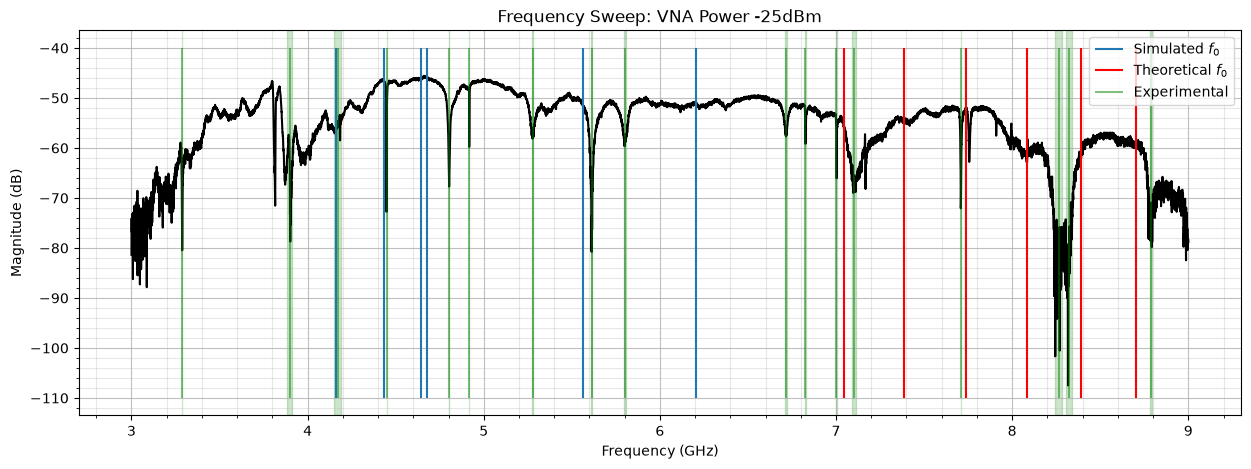

In [12]:
df_3_9GHz_25dBm_250605_205417 = pd.read_csv('Data/TWPA_on_S21_3.00-9.00GHz_-25.0dBm_20250605_205417.csv')

fig, ax = plt.subplots(figsize = (15,5))

ax.set_title('Frequency Sweep: VNA Power -25dBm')
ax.set_ylabel('Magnitude (dB)')
ax.set_xlabel('Frequency (GHz)')
ax.plot(df_3_9GHz_25dBm_250605_205417['Frequency (GHz)'],
         df_3_9GHz_25dBm_250605_205417['Magnitude (dB)'],
         c='black',ls='-')
plt.vlines(sim_f0_kin_res,ymin=-110,ymax=-40,label=r'Simulated $f_0$')
plt.vlines(theo_f0_kin_res,ymin=-110,ymax=-40,colors='r',label=r'Theoretical $f_0$')
subset = result[result['n_sweeps'] > n]

ax.vlines(subset['mean_freq_GHz'], ymin=-110, ymax=-40, colors='g', alpha=0.5, label='Experimental')

#Plot Error of results
for _, row in subset.iterrows():
    ax.axvspan(row['mean_freq_GHz'] - row['std_GHz'],
               row['mean_freq_GHz'] + row['std_GHz'],
               alpha=0.2, color='green')

ax.grid(which='major',alpha=0.8)
ax.grid(which='minor',alpha=0.3)
ax.legend(loc='best')
ax.minorticks_on()
plt.show()